In [1]:
import sys
sys.path.append(r"C:\dev\LEAP\build\lib")
from leapctype import *
from pathlib import Path

import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import tifffile


In [33]:
# folder = r'D:\NMAR\test_01\nmar_vol'
root_output_dir = Path(r'D:\NMAR\Case_02_Deliverables')

raw_dcm_path = r"D:\NMAR\Case_02_MFOV_Foot\2.16.840.114490.20251103153455\2.16.840.114490.20251103153455.896634811036079469160819174862852"
os.makedirs(root_output_dir, exist_ok=True)

metal_trace_path = r"D:\NMAR\Case_02_MFOV_Foot\cbrecon\2.16.840.114490.20251103153455_metal_thickness_fp.npy"
mask_dir = root_output_dir / "metal_mask"
mask_dir.mkdir(parents=True, exist_ok=True)

In [34]:
leapct = tomographicModels()

def load_raw_projection_dicom(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    raw_proj = ds.pixel_array.astype(np.float32)
    return ds, raw_proj

def extract_cbct_geometry_from_dcm(ds, raw_proj):
    num_views, det_rows, det_cols = raw_proj.shape

    val = getattr(ds, "ImagerPixelSpacing", None)
    if val is None:
        val = getattr(ds, "PixelSpacing", None)

    if isinstance(val, (list, tuple)):
        pixel_height, pixel_width = map(float, val)
    elif val is not None:
        pixel_height = pixel_width = float(val)
    else:
        pixel_height = pixel_width = 1.0

    center_row = 0.5 * (det_rows - 1)
    center_col = 0.5 * (det_cols - 1)

    sod = float(getattr(ds, "DistanceSourceToPatient", 462.817))
    sdd = float(getattr(ds, "DistanceSourceToDetector", 724.296))

    angles_deg = np.linspace(0, 360, num_views, endpoint=False).astype(np.float32)

    return {
        "num_views": num_views,
        "det_rows": det_rows,
        "det_cols": det_cols,
        "pixel_height": pixel_height,
        "pixel_width": pixel_width,
        "center_row": center_row,
        "center_col": center_col,
        "angles_deg": angles_deg,
        "sod": sod,
        "sdd": sdd,
    }

def setup_conebeam(geom):
    # PanelUOffset = 0.392
    # PanelVOffset = 37.746
    # PanelUOffset = 0

    PanelUOffset = 0
    PanelVOffset = 0


    print('geom["pixel_width]: ', geom["pixel_width"])
    u_offset_pix = PanelUOffset / geom["pixel_width"]
    v_offset_pix = PanelVOffset / geom["pixel_height"]

    # center_col = 0.5 * (geom["det_cols"] - 1) + u_offset_pix
    # center_row = 0.5 * (geom["det_rows"] - 1) + v_offset_pix

    leapct.set_conebeam(
        numAngles=geom["num_views"],
        numRows=geom["det_rows"],
        numCols=geom["det_cols"],
        pixelHeight=geom["pixel_height"],
        pixelWidth=geom["pixel_width"],
        # centerRow=geom["center_row"],
        # centerCol=geom["center_col"],
        # centerRow= 0.5 * (geom["det_cols"] - 1) + u_offset_pix,
        # centerCol = 0.5 * (geom["det_rows"] - 1) + v_offset_pix,
        centerRow = geom["center_row"] + u_offset_pix,
        centerCol = geom["center_col"] + v_offset_pix,
        phis=geom["angles_deg"].astype(np.float32),
        # phis=np.mod(geom["angles_deg"] - 90.0, 360.0).astype(np.float32),
        sod=geom["sod"],
        sdd=geom["sdd"],
    )

def setup_volume_from_mask(metal_vol, voxel_size_mm=0.5):
    nz, ny, nx = metal_vol.shape

    # Adjust this call to your LEAP volume API if the signature differs.
    leapct.set_volume(
        numX=nx,
        numY=ny,
        numZ=nz,
        voxelWidth=voxel_size_mm,
        voxelHeight=voxel_size_mm
    )

def allocate_and_project(volume):
    g = leapct.allocate_projections()
    f = leapct.allocate_volume()

    print("Input volume shape:", volume.shape)
    print("LEAP volume shape:", None if f is None else f.shape)

    if f.shape != volume.shape:
        raise ValueError(f"Volume shape mismatch: LEAP {f.shape} vs input {volume.shape}")

    f[:] = volume.astype(np.float32)
    leapct.project(g, f)
    return g.copy()

metal_trace shape: (720, 768, 1024)


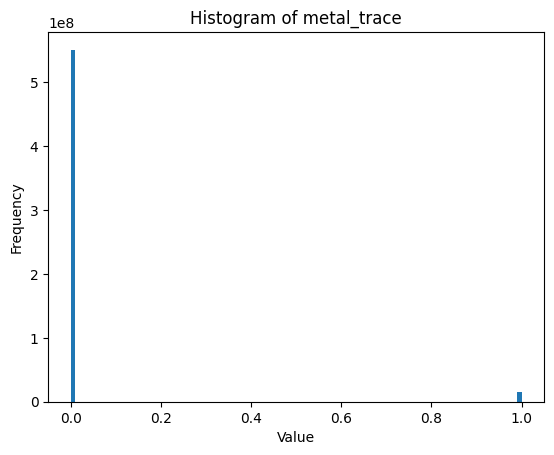

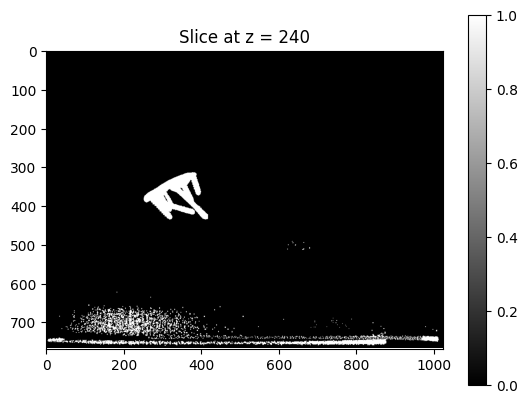

In [38]:
# metal_trace = tifffile.imread(metal_trace_path)
metal_trace = np.load(metal_trace_path)

metal_trace = (metal_trace > 0).astype(np.float32)
# metal_trace = (metal_trace > 0)
metal_trace = metal_trace.transpose(0, 1, 2)

print("metal_trace shape:", metal_trace.shape)
v = metal_trace.shape[0] // 3

vals = metal_trace.ravel()

plt.hist(vals, bins=100)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of metal_trace")
plt.show()

slice_2d = metal_trace[v].astype(np.uint8)

plt.imshow(slice_2d, cmap='gray')
plt.colorbar()
plt.title(f"Slice at z = {v}")
plt.show()

np.save(mask_dir / "metal_mask.npy", metal_trace)

raw_proj shape: (720, 768, 1024)


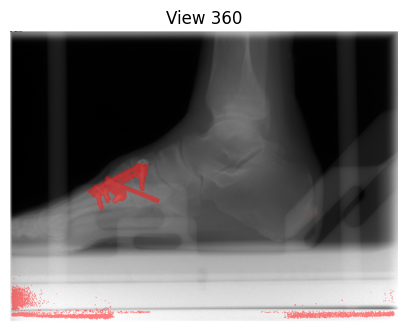

In [39]:
ds, raw_proj = load_raw_projection_dicom(raw_dcm_path)
print("raw_proj shape:", raw_proj.shape)



I = raw_proj.astype(np.float32)
I0 = np.percentile(I, 99.0)
proj_log = -np.log(np.clip(I / I0, 1e-6, None))

v = 360
raw = proj_log[v] if 'proj_log' in locals() else raw_proj[v]
mask = metal_trace[v]
        # mask = mask_trace[v]
        # mask = metal_trace_fixed[v]
        # mask = metal_trace[(v - shift) % proj_log.shape[0]]

p1, p99 = np.percentile(raw, (1, 99))
raw_norm = np.clip((raw - p1) / (p99 - p1 + 1e-6), 0, 1)

rgb = np.stack([raw_norm, raw_norm, raw_norm], axis=-1)

alpha = 0.5
rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])
rgb[..., 1] = np.where(mask, (1 - alpha) * rgb[..., 1], rgb[..., 1])
rgb[..., 2] = np.where(mask, (1 - alpha) * rgb[..., 2], rgb[..., 2])

plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title(f"View {v}")
plt.axis("off")
plt.show()


In [37]:
def load_dicom_series_hu(folder):
    slices = []

    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            ds = pydicom.dcmread(path)
            slices.append(ds)
        except:
            continue

    # sort slices (important)
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

    # stack raw pixel data
    vol = np.stack([s.pixel_array for s in slices]).astype(np.float32)

    # apply HU scaling
    slope = getattr(slices[0], "RescaleSlope", 1.0)
    intercept = getattr(slices[0], "RescaleIntercept", 0.0)

    vol_hu = vol * slope + intercept
    return vol_hu, slices

# ---- usage ----
# folder = "path/to/dicom_dir"
vol_hu, slices = load_dicom_series_hu(folder)

# flatten + optional clipping
vals = vol_hu.flatten()
vals = np.clip(vals, -1000, 20000)  # typical CT range

# plot histogram
plt.figure()
plt.hist(vals, bins=200, log = True)
plt.xlim(1000, 3000)
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Voxel Count")
plt.title("CT Histogram (HU scaled)")
plt.show()

NameError: name 'folder' is not defined

In [5]:
threshold = 2200

In [6]:
from pathlib import Path
import numpy as np

threshold_hu = 2200
# root_output_dir = Path("/path/to/output_root")
mask_dir = root_output_dir / "metal_mask"
mask_dir.mkdir(parents=True, exist_ok=True)

metal_mask = (vol_hu > threshold_hu).astype(np.uint8)

np.save(mask_dir / "metal_mask.npy", metal_mask)

print("saved:", mask_dir / "metal_mask.npy")
print("shape:", metal_mask.shape)
print("metal voxels:", int(metal_mask.sum()))


saved: D:\NMAR\Case_01_Deliverables\metal_mask\metal_mask.npy
shape: (630, 840, 840)
metal voxels: 168173


In [7]:
from pathlib import Path
import pydicom

dcm_dir = mask_dir / "dcm"
dcm_dir.mkdir(parents=True, exist_ok=True)

for i, ds in enumerate(slices):
    out_ds = ds.copy()

    slice_mask = metal_mask[i].astype(np.uint16)   # 0 or 1

    out_ds.Rows, out_ds.Columns = slice_mask.shape
    out_ds.PixelData = slice_mask.tobytes()

    out_ds.SamplesPerPixel = 1
    out_ds.PhotometricInterpretation = "MONOCHROME2"
    out_ds.BitsAllocated = 16
    out_ds.BitsStored = 16
    out_ds.HighBit = 15
    out_ds.PixelRepresentation = 0

    out_ds.RescaleSlope = 1
    out_ds.RescaleIntercept = 0
    out_ds.WindowCenter = 0.5
    out_ds.WindowWidth = 1

    out_path = dcm_dir / f"metal_mask_{i:04d}.dcm"
    out_ds.save_as(str(out_path))

print("saved dicoms to:", dcm_dir)

saved dicoms to: D:\NMAR\Case_01_Deliverables\metal_mask\dcm


In [8]:
ds, raw_proj = load_raw_projection_dicom(raw_dcm_path)
print("raw_proj shape:", raw_proj.shape)

geom = extract_cbct_geometry_from_dcm(ds, raw_proj)
setup_conebeam(geom)
setup_volume_from_mask(metal_mask, voxel_size_mm=0.3)

# # # 5) Forward project metal mask
metal_proj = allocate_and_project(metal_mask)
# metal_trace = metal_proj > 1e-6
# #
metal_trace = metal_proj > (0.02 * metal_proj.max())

np.save(os.path.join(mask_dir, "metal_proj.npy"), metal_proj)
np.save(os.path.join(mask_dir, "metal_trace.npy"), metal_trace.astype(np.uint8))


raw_proj shape: (480, 768, 1024)
geom["pixel_width]:  0.388
Input volume shape: (630, 840, 840)
LEAP volume shape: (630, 840, 840)


In [11]:
# print("raw_proj:", raw_proj.shape)
# print("proj_log:", proj_log.shape)
# print("metal_trace:", metal_trace.shape)

raw_proj: (480, 768, 1024)


NameError: name 'proj_log' is not defined

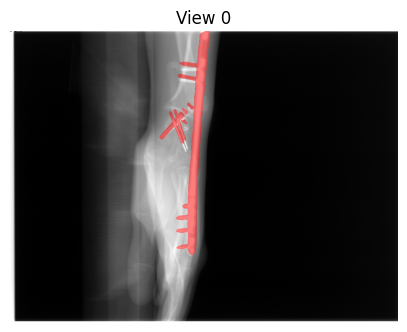

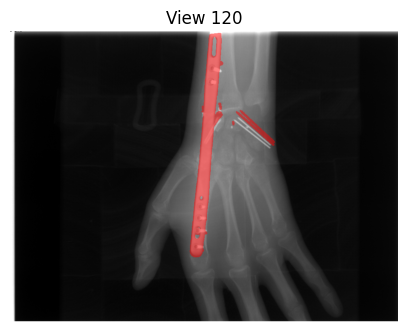

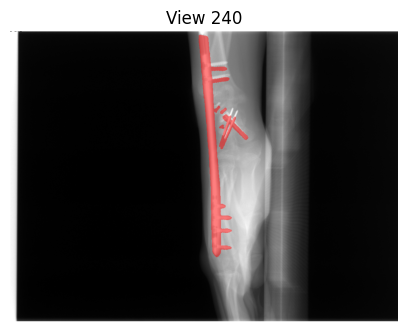

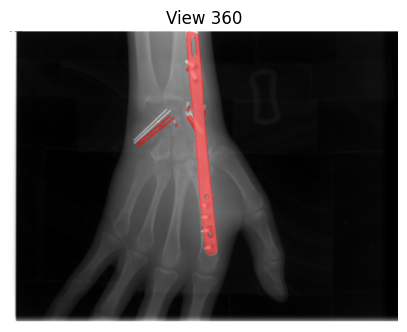

In [16]:
I = raw_proj.astype(np.float32)
I0 = np.percentile(I, 99.9)
proj_log = -np.log(np.clip(I / I0, 1e-6, None))

N = proj_log.shape[0]
# shift = N // 4
shift = 120

metal_trace_bkwd = metal_trace[::-1,:,:]

metal_trace_corr = np.empty_like(metal_trace)
for v in range(N):
    metal_trace_corr[v] = metal_trace_bkwd[(v + shift) % N,::-1,:]
    # metal_trace_corr[v] = metal_trace[:,::-1,:][(v - shift) % N]

# ✅ Save corrected trace
save_path = os.path.join(mask_dir, "metal_trace_corr.npy")
np.save(save_path, metal_trace_corr)

for v in [0, 120, 240, 360]:
        raw = proj_log[v] if 'proj_log' in locals() else raw_proj[v]
        mask = metal_trace_corr[v]
        # mask = mask_trace[v]
        # mask = metal_trace_fixed[v]
        # mask = metal_trace[(v - shift) % proj_log.shape[0]]

        p1, p99 = np.percentile(raw, (1, 99))
        raw_norm = np.clip((raw - p1) / (p99 - p1 + 1e-6), 0, 1)

        rgb = np.stack([raw_norm, raw_norm, raw_norm], axis=-1)

        alpha = 0.5
        rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])
        rgb[..., 1] = np.where(mask, (1 - alpha) * rgb[..., 1], rgb[..., 1])
        rgb[..., 2] = np.where(mask, (1 - alpha) * rgb[..., 2], rgb[..., 2])

        out_path = os.path.join(mask_dir, f"metal_trace02_overlay_{v:04d}.tif")
        tifffile.imwrite(out_path, (rgb * 255).astype(np.uint8))

           # 👇 Show instead of save
        plt.figure(figsize=(5, 5))
        plt.imshow(rgb)
        plt.title(f"View {v}")
        plt.axis("off")
        plt.show()



## not used

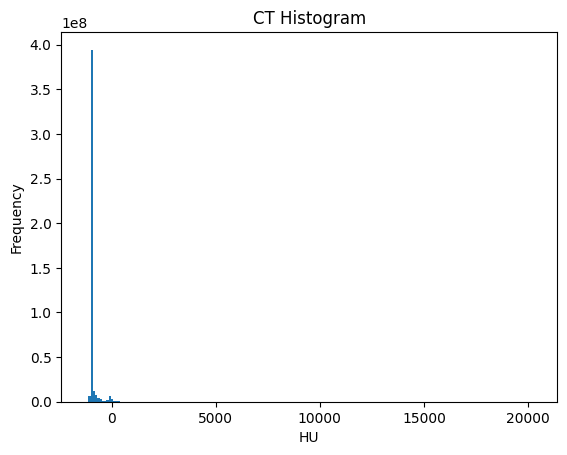

In [25]:

# def load_dicom_series(folder):
#     slices = []
    
#     for fname in os.listdir(folder):
#         path = os.path.join(folder, fname)
#         try:
#             ds = pydicom.dcmread(path)
#             slices.append(ds)
#         except:
#             continue

#     # sort by slice position (important!)
#     slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

#     # stack into 3D volume
#     volume = np.stack([s.pixel_array for s in slices]).astype(np.float32)

#     # convert to HU if needed
#     if hasattr(slices[0], 'RescaleSlope'):
#         slope = slices[0].RescaleSlope
#         intercept = slices[0].RescaleIntercept
#         volume = volume * slope + intercept

#     return volume

# # ---- usage ----
# # folder = "path/to/dicom_dir"
# vol = load_dicom_series(folder)

# # flatten and plot histogram
# vals = vol.flatten()

# plt.figure()
# plt.hist(vals, bins=200)
# plt.xlabel("HU")
# plt.ylabel("Frequency")
# plt.title("CT Histogram")
# plt.show()





C:\Users\stuti.singh\AppData\Local\Temp\ipykernel_36776\1844376985.py:16: RuntimeWarning: divide by zero encountered in scalar floor_divide
  shift = N // k


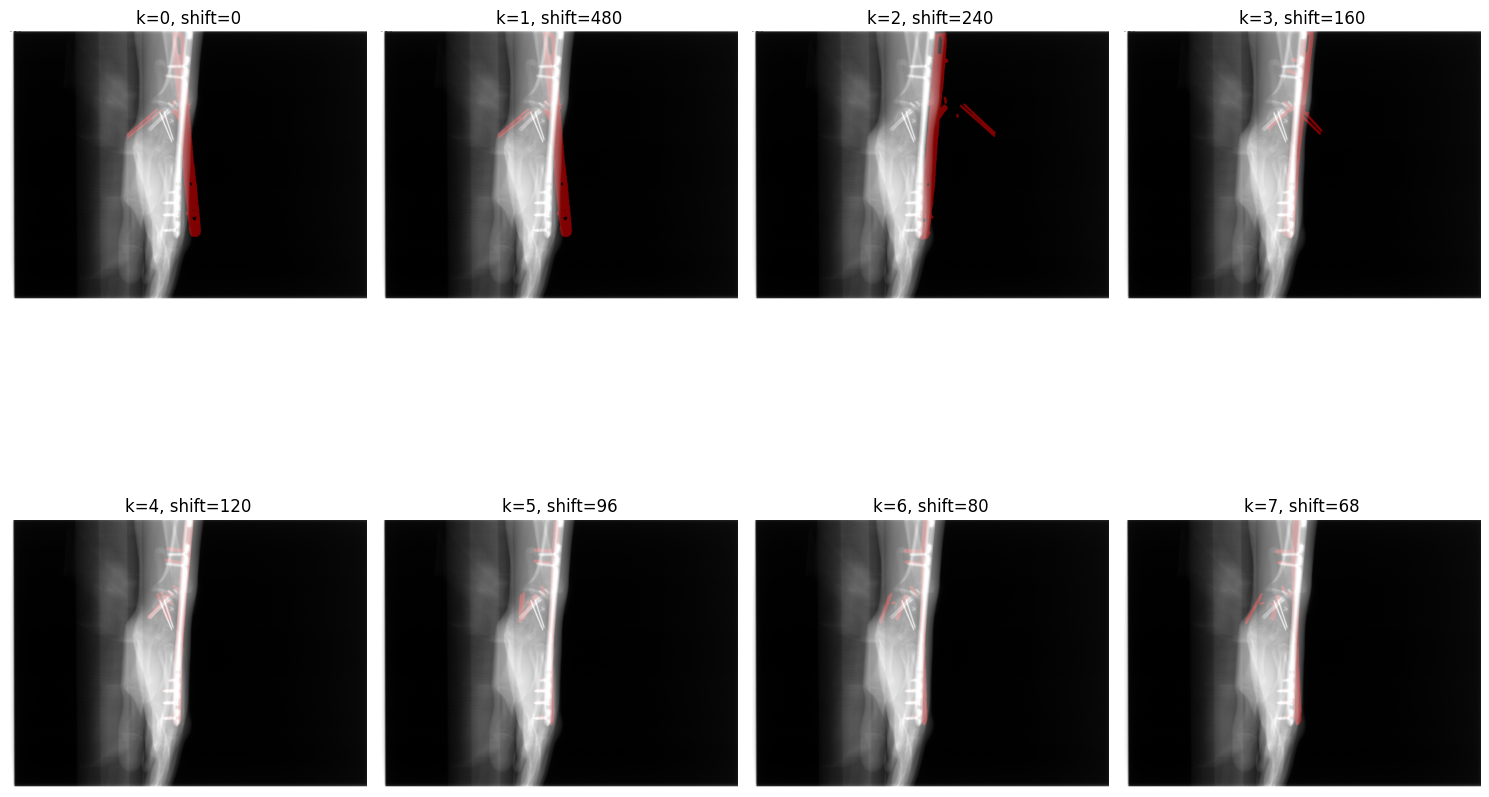

In [15]:
import matplotlib.pyplot as plt

I = raw_proj.astype(np.float32)
I0 = np.percentile(I, 99.9)
proj_log = -np.log(np.clip(I / I0, 1e-6, None))

N = proj_log.shape[0]

# pick one or a few views to visualize
views = [0]  # you can add more like [0, 120]

fig, axes = plt.subplots(2, 4, figsize=(15, 12))
axes = axes.flatten()
metal_trace_bkwd = metal_trace[::-1,:,:]
for idx, k in enumerate(np.arange(0, 8)):
    shift = N // k

    metal_trace_corr = np.empty_like(metal_trace)
    for v in range(N):
        metal_trace_corr[v] = metal_trace_bkwd[(v + shift) % N,::-1,:]

    # visualize first view (or loop views if you want multiple overlays)
    v = views[0]
    raw = proj_log[v]
    mask = metal_trace_corr[v]

    p1, p99 = np.percentile(raw, (1, 99))
    raw_norm = np.clip((raw - p1) / (p99 - p1 + 1e-6), 0, 1)
    rgb = np.stack([raw_norm]*3, axis=-1)

    alpha = 0.5
    rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])

    ax = axes[idx]
    ax.imshow(rgb)
    ax.set_title(f"k={k}, shift={shift}")
    ax.axis("off")

plt.tight_layout()
plt.show()

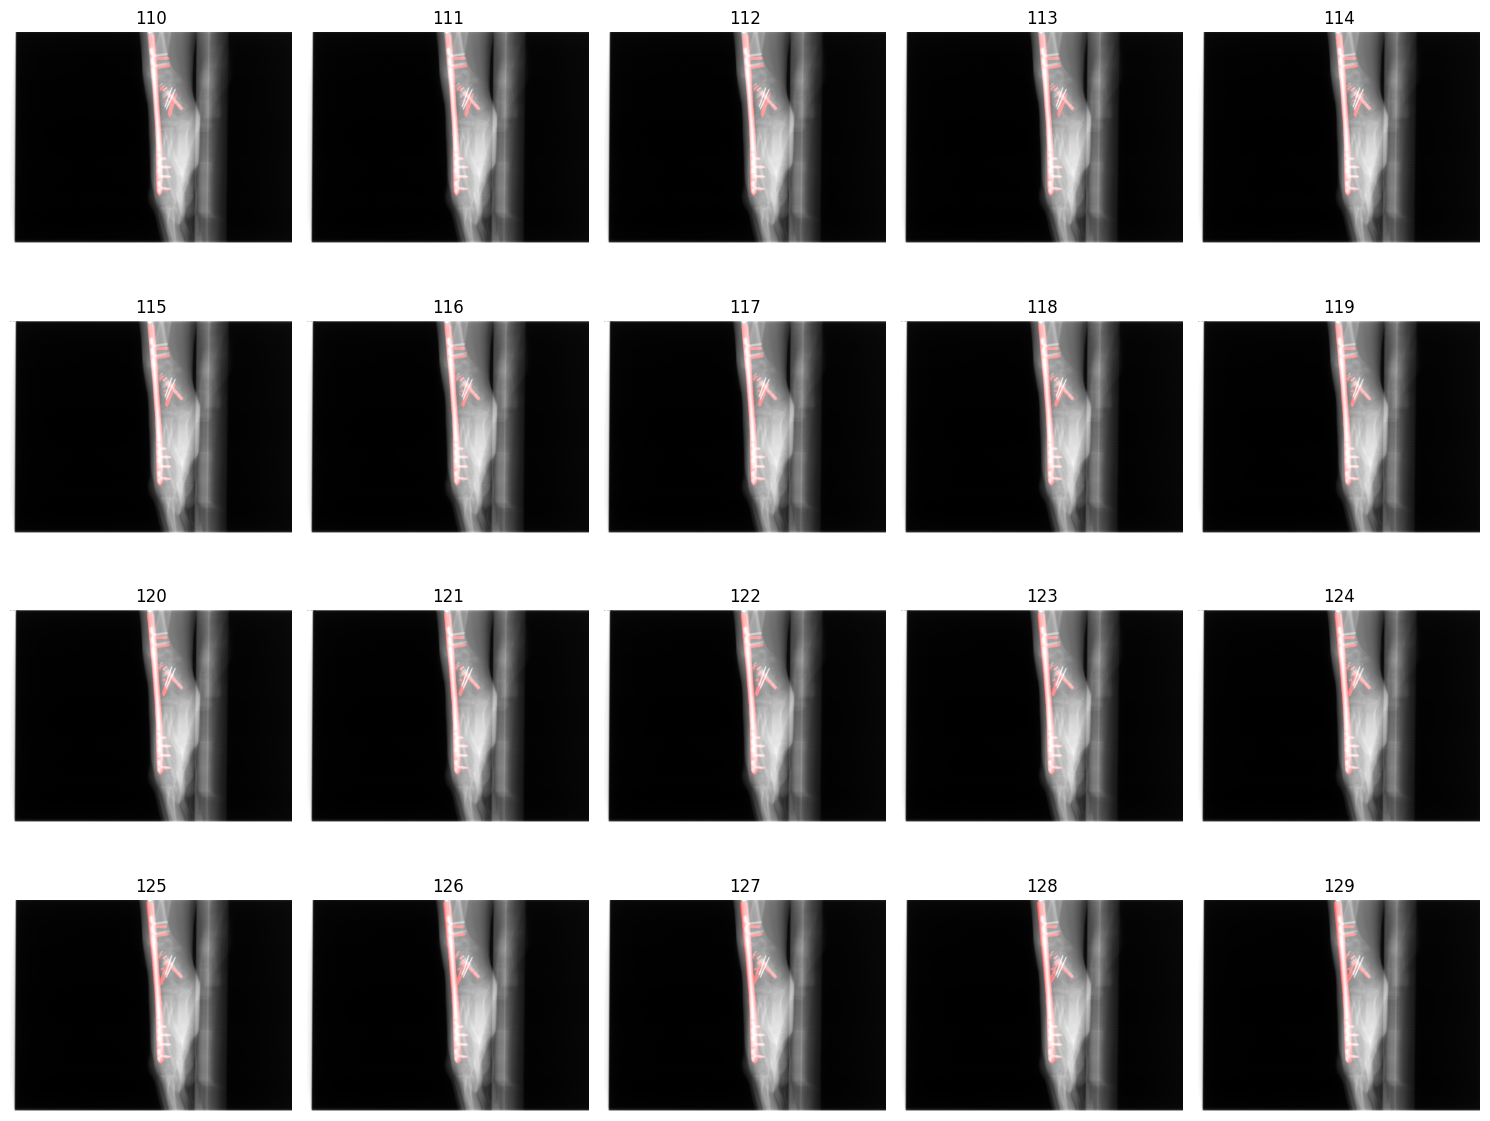

In [166]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

metal_trace_bkwd = metal_trace[::-1,:,:]

for i, delta in enumerate(range(-10, 10)):
    shift = 120 + delta

    v = 240
    mask = metal_trace_bkwd[(v + shift) % N, ::-1, :]
    raw = proj_log[v]

    p1, p99 = np.percentile(raw, (1, 99))
    raw_norm = np.clip((raw - p1) / (p99 - p1 + 1e-6), 0, 1)
    rgb = np.stack([raw_norm]*3, axis=-1)

    rgb[..., 0] = np.where(mask, 1.0, rgb[..., 0])

    ax = axes[i]
    ax.imshow(rgb)
    ax.set_title(f"{shift}")
    ax.axis("off")

plt.tight_layout()
plt.show()